In [1]:
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn.preprocessing import LabelEncoder



### reading all the csv files and storing into df

### Note
### I have taken only 15 csv files
##### more csv files need more power and time 

In [2]:
import pandas as pd
import glob

df_list = []
for file in glob.glob('*_tracks.csv'):
    df = pd.read_csv(file)
    df_list.append(df)

df_combined = pd.concat(df_list, ignore_index=True)
df = df_combined

# Reset the dataset 

In [3]:
 tracks_df = df

In [4]:
df1 = df

In [5]:
df.isna().any()

frame                 False
id                    False
x                     False
y                     False
width                 False
height                False
xVelocity             False
yVelocity             False
xAcceleration         False
yAcceleration         False
frontSightDistance    False
backSightDistance     False
dhw                   False
thw                   False
ttc                   False
precedingXVelocity    False
precedingId           False
followingId           False
leftPrecedingId       False
leftAlongsideId       False
leftFollowingId       False
rightPrecedingId      False
rightAlongsideId      False
rightFollowingId      False
laneId                False
dtype: bool

In [6]:
df.apply(lambda x: x.isna().all()).value_counts()


False    25
Name: count, dtype: int64

### As we can see we dont have na values so we dont need to apply interpolation

In [7]:
tracks_df

,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,yAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
0,1,1,362.26,21.68,4.85,2.12,40.85,0.00,0.30,0.00,...,0.00,0,3,0,0,0,0,0,6,5
1,2,1,363.73,21.68,4.85,2.12,40.87,0.00,0.30,0.00,...,0.00,0,14,0,0,0,0,0,6,5
2,3,1,365.27,21.68,4.85,2.12,40.88,0.00,0.31,0.00,...,0.00,0,14,0,0,0,0,0,6,5
3,4,1,366.83,21.68,4.85,2.12,40.89,0.00,0.32,0.00,...,0.00,0,14,0,0,0,0,0,6,5
4,5,1,368.42,21.68,4.85,2.12,40.90,0.01,0.32,0.00,...,0.00,0,14,0,0,0,0,0,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17944192,30047,2479,47.22,21.62,4.85,1.92,34.11,0.13,0.05,0.07,...,36.51,2477,0,0,0,0,2478,0,0,6
17944193,30048,2479,48.58,21.62,4.85,1.92,34.11,0.13,0.05,0.07,...,36.52,2477,0,0,0,0,2478,0,0,6
17944194,30049,2479,49.95,21.63,4.85,1.92,34.11,0.13,0.05,0.07,...,36.52,2477,0,0,0,0,2478,0,0,6
17944195,30050,2479,51.31,21.63,4.85,1.92,34.11,0.14,0.05,0.07,...,36.52,2477,0,0,0,0,2478,0,0,6


#### removing all the invalid values

In [8]:
tracks_df = tracks_df[
    (tracks_df["yVelocity"].between(0, 2)) &
    (tracks_df["dhw"] > 0) &
    (tracks_df["ttc"].between(0 ,4))
]

In [9]:
tracks_df

,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,yAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
16362,1331,58,172.11,10.66,4.55,1.92,-35.38,0.66,0.07,0.13,...,-22.37,52,62,57,0,61,0,0,0,2
16363,1332,58,170.70,10.69,4.55,1.92,-35.38,0.66,0.08,0.12,...,-22.37,52,62,57,0,61,0,0,0,2
16364,1333,58,169.29,10.71,4.55,1.92,-35.38,0.67,0.09,0.12,...,-22.37,52,62,57,0,61,0,0,0,2
16365,1334,58,167.87,10.74,4.55,1.92,-35.37,0.67,0.09,0.11,...,-22.37,52,62,57,0,61,0,0,0,2
16366,1335,58,166.46,10.77,4.55,1.92,-35.37,0.68,0.10,0.10,...,-22.37,52,62,57,0,61,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17862928,26695,2240,348.59,10.36,4.35,1.82,-37.09,1.19,-0.34,0.28,...,-24.77,2236,0,2238,0,2241,2233,0,2243,3
17862929,26696,2240,347.12,10.40,4.35,1.82,-37.10,1.21,-0.33,0.27,...,-24.76,2236,0,2238,0,2241,2233,0,2243,3
17862930,26697,2240,345.63,10.45,4.35,1.82,-37.12,1.23,-0.31,0.25,...,-24.76,2236,0,2238,0,2241,2233,0,2243,3
17862931,26698,2240,344.15,10.50,4.35,1.82,-37.13,1.25,-0.29,0.24,...,-24.76,2236,0,2238,0,2241,2233,0,2243,3


In [10]:
tracks_df.describe()

,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,yAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
count,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,...,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000
mean,13102.077561,991.088429,207.490200,14.107193,5.261516,1.988288,-20.087534,0.564460,0.255686,0.078271,...,-15.322914,986.283876,805.014014,596.277698,105.036092,467.052165,615.566779,223.389292,582.560716,2.950638
std,7967.778515,729.160873,107.820995,6.028305,2.205015,0.202387,18.353239,0.468339,0.968752,0.174274,...,15.104581,728.243948,803.606049,680.641501,405.567152,669.290816,821.105249,592.936372,814.751603,1.078447
min,1.000000,4.000000,2.110000,3.480000,2.830000,1.720000,-55.550000,-0.000000,-4.310000,-0.460000,...,-39.720000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,5628.500000,401.000000,123.285000,9.740000,4.450000,1.820000,-33.620000,0.040000,-0.370000,-0.020000,...,-25.210000,398.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,12777.000000,827.000000,203.950000,12.610000,4.750000,1.920000,-27.600000,0.660000,0.070000,0.010000,...,-23.120000,824.000000,592.000000,376.000000,0.000000,0.000000,148.000000,0.000000,61.000000,3.000000
75%,19126.500000,1450.000000,297.795000,18.990000,5.050000,2.020000,-6.380000,0.960000,0.810000,0.160000,...,-3.510000,1428.000000,1278.000000,976.000000,0.000000,767.000000,1085.000000,0.000000,1005.000000,3.000000
max,30055.000000,2841.000000,406.870000,39.900000,19.400000,3.030000,45.370000,2.000000,4.200000,0.770000,...,39.920000,2835.000000,2818.000000,2830.000000,2790.000000,2837.000000,2838.000000,2821.000000,2830.000000,8.000000


#### Detecting the Outliers

In [11]:
tracks_df = df

In [12]:
tracks_df = tracks_df[
    (tracks_df["yVelocity"].between(0, 2)) &
    (tracks_df["dhw"] > 0) &
    (tracks_df["ttc"].between(0, 4))
]

In [13]:
tracks_df.describe()

,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,yAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
count,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,...,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000
mean,13102.077561,991.088429,207.490200,14.107193,5.261516,1.988288,-20.087534,0.564460,0.255686,0.078271,...,-15.322914,986.283876,805.014014,596.277698,105.036092,467.052165,615.566779,223.389292,582.560716,2.950638
std,7967.778515,729.160873,107.820995,6.028305,2.205015,0.202387,18.353239,0.468339,0.968752,0.174274,...,15.104581,728.243948,803.606049,680.641501,405.567152,669.290816,821.105249,592.936372,814.751603,1.078447
min,1.000000,4.000000,2.110000,3.480000,2.830000,1.720000,-55.550000,-0.000000,-4.310000,-0.460000,...,-39.720000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,5628.500000,401.000000,123.285000,9.740000,4.450000,1.820000,-33.620000,0.040000,-0.370000,-0.020000,...,-25.210000,398.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,12777.000000,827.000000,203.950000,12.610000,4.750000,1.920000,-27.600000,0.660000,0.070000,0.010000,...,-23.120000,824.000000,592.000000,376.000000,0.000000,0.000000,148.000000,0.000000,61.000000,3.000000
75%,19126.500000,1450.000000,297.795000,18.990000,5.050000,2.020000,-6.380000,0.960000,0.810000,0.160000,...,-3.510000,1428.000000,1278.000000,976.000000,0.000000,767.000000,1085.000000,0.000000,1005.000000,3.000000
max,30055.000000,2841.000000,406.870000,39.900000,19.400000,3.030000,45.370000,2.000000,4.200000,0.770000,...,39.920000,2835.000000,2818.000000,2830.000000,2790.000000,2837.000000,2838.000000,2821.000000,2830.000000,8.000000


In [14]:
from scipy.signal import savgol_filter

def smooth_signal(series):
    if len(series) >= 7:
        return savgol_filter(series, 7, 2)
    return series

tracks_df = tracks_df.sort_values(["id", "frame"])

for col in ["yVelocity","dhw"]:
    tracks_df[col] = (
        tracks_df.groupby("id")[col]
        .transform(smooth_signal)
    )


In [15]:
tracks_df

,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,yAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
3018984,79,4,334.91,20.11,4.45,1.92,40.66,0.150952,1.03,-0.04,...,36.60,3,12,0,0,0,0,5,0,6
3018985,80,4,336.54,20.12,4.45,1.92,40.70,0.150000,1.03,-0.05,...,36.60,3,12,0,0,0,0,5,0,6
3018986,81,4,338.17,20.12,4.45,1.92,40.75,0.148571,1.04,-0.06,...,36.61,3,12,0,0,0,0,5,0,6
3018987,82,4,339.80,20.13,4.45,1.92,40.79,0.146667,1.05,-0.07,...,36.62,3,12,0,0,0,0,5,0,6
3018988,83,4,341.45,20.14,4.45,1.92,40.83,0.144286,1.05,-0.08,...,36.62,3,12,0,0,0,0,5,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12946349,29369,2841,21.77,33.62,4.75,1.82,6.74,0.800952,0.40,0.03,...,2.74,2835,0,0,0,0,2838,0,0,6
12946350,29370,2841,22.01,33.65,4.75,1.82,6.75,0.800000,0.40,0.01,...,2.74,2835,0,0,0,0,2838,0,0,6
12946351,29371,2841,22.26,33.69,4.75,1.82,6.77,0.800000,0.40,0.00,...,2.75,2835,0,0,0,0,2838,0,0,6
12946352,29372,2841,22.52,33.72,4.75,1.82,6.79,0.800000,0.41,-0.01,...,2.75,2835,0,0,0,0,2838,0,0,6


In [16]:
tracks_df.describe()

,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,yAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
count,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,...,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000
mean,13102.077561,991.088429,207.490200,14.107193,5.261516,1.988288,-20.087534,0.564461,0.255686,0.078271,...,-15.322914,986.283876,805.014014,596.277698,105.036092,467.052165,615.566779,223.389292,582.560716,2.950638
std,7967.778515,729.160873,107.820995,6.028305,2.205015,0.202387,18.353239,0.467621,0.968752,0.174274,...,15.104581,728.243948,803.606049,680.641501,405.567152,669.290816,821.105249,592.936372,814.751603,1.078447
min,1.000000,4.000000,2.110000,3.480000,2.830000,1.720000,-55.550000,-0.116190,-4.310000,-0.460000,...,-39.720000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,5628.500000,401.000000,123.285000,9.740000,4.450000,1.820000,-33.620000,0.040714,-0.370000,-0.020000,...,-25.210000,398.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,12777.000000,827.000000,203.950000,12.610000,4.750000,1.920000,-27.600000,0.660000,0.070000,0.010000,...,-23.120000,824.000000,592.000000,376.000000,0.000000,0.000000,148.000000,0.000000,61.000000,3.000000
75%,19126.500000,1450.000000,297.795000,18.990000,5.050000,2.020000,-6.380000,0.957143,0.810000,0.160000,...,-3.510000,1428.000000,1278.000000,976.000000,0.000000,767.000000,1085.000000,0.000000,1005.000000,3.000000
max,30055.000000,2841.000000,406.870000,39.900000,19.400000,3.030000,45.370000,2.000000,4.200000,0.770000,...,39.920000,2835.000000,2818.000000,2830.000000,2790.000000,2837.000000,2838.000000,2821.000000,2830.000000,8.000000


In [17]:
tracks_df

,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,yAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
3018984,79,4,334.91,20.11,4.45,1.92,40.66,0.150952,1.03,-0.04,...,36.60,3,12,0,0,0,0,5,0,6
3018985,80,4,336.54,20.12,4.45,1.92,40.70,0.150000,1.03,-0.05,...,36.60,3,12,0,0,0,0,5,0,6
3018986,81,4,338.17,20.12,4.45,1.92,40.75,0.148571,1.04,-0.06,...,36.61,3,12,0,0,0,0,5,0,6
3018987,82,4,339.80,20.13,4.45,1.92,40.79,0.146667,1.05,-0.07,...,36.62,3,12,0,0,0,0,5,0,6
3018988,83,4,341.45,20.14,4.45,1.92,40.83,0.144286,1.05,-0.08,...,36.62,3,12,0,0,0,0,5,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12946349,29369,2841,21.77,33.62,4.75,1.82,6.74,0.800952,0.40,0.03,...,2.74,2835,0,0,0,0,2838,0,0,6
12946350,29370,2841,22.01,33.65,4.75,1.82,6.75,0.800000,0.40,0.01,...,2.74,2835,0,0,0,0,2838,0,0,6
12946351,29371,2841,22.26,33.69,4.75,1.82,6.77,0.800000,0.40,0.00,...,2.75,2835,0,0,0,0,2838,0,0,6
12946352,29372,2841,22.52,33.72,4.75,1.82,6.79,0.800000,0.41,-0.01,...,2.75,2835,0,0,0,0,2838,0,0,6


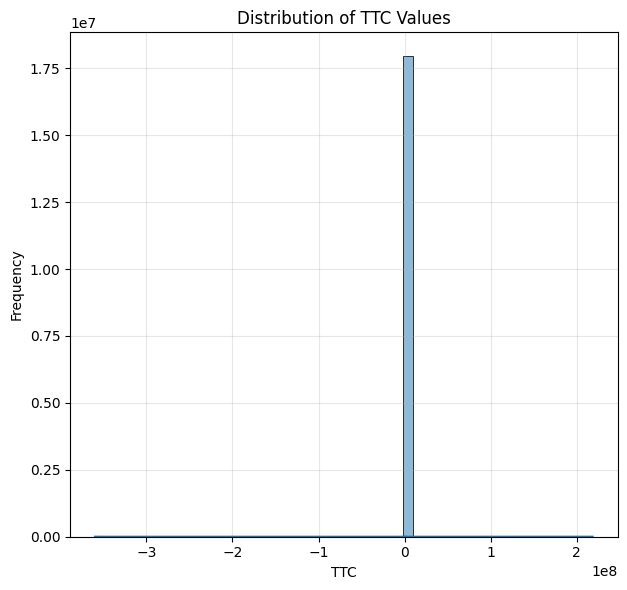

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Histogram with density curve
plt.subplot(1, 2, 1)
sns.histplot(df['ttc'], kde=True, bins=50)
plt.title('Distribution of TTC Values')
plt.xlabel('TTC')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

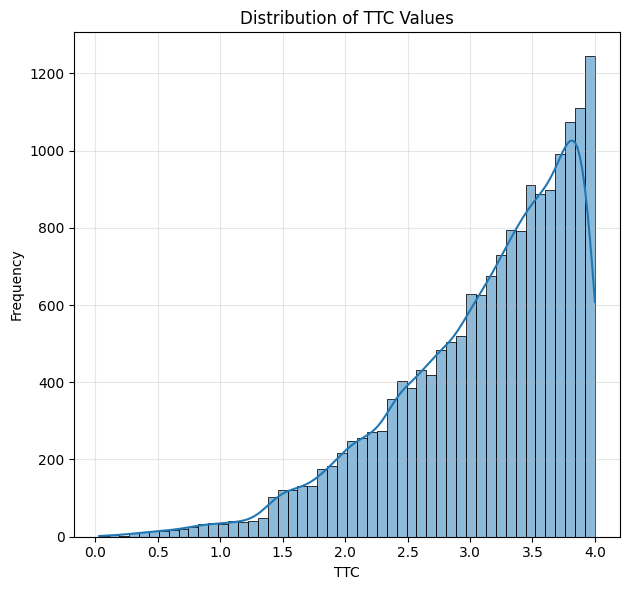

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Histogram with density curve
plt.subplot(1, 2, 1)
sns.histplot(tracks_df['ttc'], kde=True, bins=50)
plt.title('Distribution of TTC Values')
plt.xlabel('TTC')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

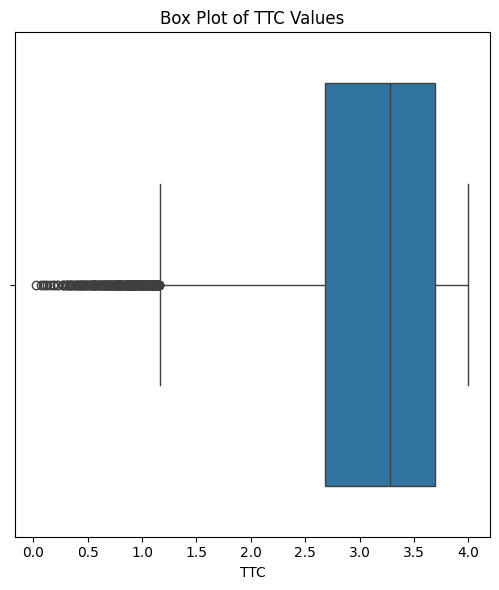

In [20]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=tracks_df['ttc'])
plt.title('Box Plot of TTC Values')
plt.xlabel('TTC')



plt.tight_layout()
plt.show()

#### Synchronisation

In [21]:
tracks_df["time"] = pd.to_timedelta(tracks_df["frame"] / 25.0, unit="s")

tracks_df_syn = (
    tracks_df
    .set_index("time")
    .groupby("id")
    .apply(lambda x: x.resample("40ms").mean())
    .reset_index(level=0, drop=True)
    .reset_index()
)


C:\Users\mofis\AppData\Local\Temp\ipykernel_3684\293669101.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.resample("40ms").mean())


In [22]:
tracks_df_syn

,time,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
0,0 days 00:00:03.160000,79.0,4.0,334.91,20.11,4.45,1.92,40.66,0.150952,1.03,...,36.60,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
1,0 days 00:00:03.200000,80.0,4.0,336.54,20.12,4.45,1.92,40.70,0.150000,1.03,...,36.60,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
2,0 days 00:00:03.240000,81.0,4.0,338.17,20.12,4.45,1.92,40.75,0.148571,1.04,...,36.61,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
3,0 days 00:00:03.280000,82.0,4.0,339.80,20.13,4.45,1.92,40.79,0.146667,1.05,...,36.62,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
4,0 days 00:00:03.320000,83.0,4.0,341.45,20.14,4.45,1.92,40.83,0.144286,1.05,...,36.62,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380664,0 days 00:19:34.760000,29369.0,2841.0,21.77,33.62,4.75,1.82,6.74,0.800952,0.40,...,2.74,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0
380665,0 days 00:19:34.800000,29370.0,2841.0,22.01,33.65,4.75,1.82,6.75,0.800000,0.40,...,2.74,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0
380666,0 days 00:19:34.840000,29371.0,2841.0,22.26,33.69,4.75,1.82,6.77,0.800000,0.40,...,2.75,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0
380667,0 days 00:19:34.880000,29372.0,2841.0,22.52,33.72,4.75,1.82,6.79,0.800000,0.41,...,2.75,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0


In [23]:
tracks_df["ttc"].describe()

count    17483.000000
mean         3.109006
std          0.718778
min          0.030000
25%          2.680000
50%          3.280000
75%          3.690000
max          4.000000
Name: ttc, dtype: float64

In [24]:
tracks_df_syn.isna().sum()

time                       0
frame                 363186
id                    363186
x                     363186
y                     363186
width                 363186
height                363186
xVelocity             363186
yVelocity             363186
xAcceleration         363186
yAcceleration         363186
frontSightDistance    363186
backSightDistance     363186
dhw                   363186
thw                   363186
ttc                   363186
precedingXVelocity    363186
precedingId           363186
followingId           363186
leftPrecedingId       363186
leftAlongsideId       363186
leftFollowingId       363186
rightPrecedingId      363186
rightAlongsideId      363186
rightFollowingId      363186
laneId                363186
dtype: int64

In [25]:
tracks_df.isna().sum()

frame                 0
id                    0
x                     0
y                     0
width                 0
height                0
xVelocity             0
yVelocity             0
xAcceleration         0
yAcceleration         0
frontSightDistance    0
backSightDistance     0
dhw                   0
thw                   0
ttc                   0
precedingXVelocity    0
precedingId           0
followingId           0
leftPrecedingId       0
leftAlongsideId       0
leftFollowingId       0
rightPrecedingId      0
rightAlongsideId      0
rightFollowingId      0
laneId                0
time                  0
dtype: int64

## Interpolation after synchronization
##### We have (na) value 
##### Now we have to do interpolation

In [26]:
df= tracks_df_syn

In [27]:
df[["id","frame","xVelocity", "yVelocity",
    "xAcceleration", "yAcceleration",
    "dhw", "thw", "ttc"]] = tracks_df_syn[["id","frame","xVelocity", "yVelocity",
    "xAcceleration", "yAcceleration",
    "dhw", "thw", "ttc"]].interpolate(method='linear')

In [28]:
df.isna().sum()

time                       0
frame                      0
id                         0
x                     363186
y                     363186
width                 363186
height                363186
xVelocity                  0
yVelocity                  0
xAcceleration              0
yAcceleration              0
frontSightDistance    363186
backSightDistance     363186
dhw                        0
thw                        0
ttc                        0
precedingXVelocity    363186
precedingId           363186
followingId           363186
leftPrecedingId       363186
leftAlongsideId       363186
leftFollowingId       363186
rightPrecedingId      363186
rightAlongsideId      363186
rightFollowingId      363186
laneId                363186
dtype: int64

In [29]:
df['ttc'].describe()


count    380669.000000
mean          3.375925
std           0.643160
min           0.030000
25%           3.040517
50%           3.609813
75%           3.903811
max           4.000000
Name: ttc, dtype: float64

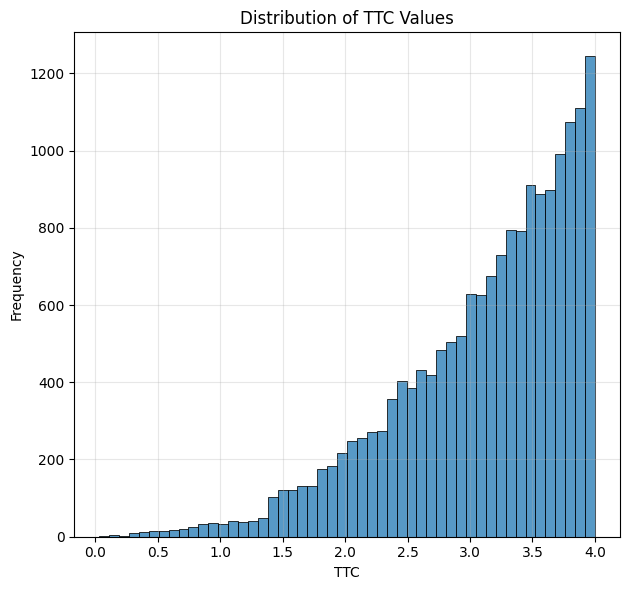

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Histogram with density curve
plt.subplot(1, 2, 1)
sns.histplot(tracks_df['ttc'], kde=False, bins=50)
plt.title('Distribution of TTC Values')
plt.xlabel('TTC')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

#### Learning

# Feature Engineering & Exploration Analyse

#### Feature Selection

In [31]:
df.isna().any()

time                  False
frame                 False
id                    False
x                      True
y                      True
width                  True
height                 True
xVelocity             False
yVelocity             False
xAcceleration         False
yAcceleration         False
frontSightDistance     True
backSightDistance      True
dhw                   False
thw                   False
ttc                   False
precedingXVelocity     True
precedingId            True
followingId            True
leftPrecedingId        True
leftAlongsideId        True
leftFollowingId        True
rightPrecedingId       True
rightAlongsideId       True
rightFollowingId       True
laneId                 True
dtype: bool

In [32]:
feature_cols = ['dhw','ttc','yVelocity']

In [33]:
feature_df = df

### Statistical Features

In [34]:
stat_features = ( df.groupby('id')[feature_cols].agg(["mean","var","std"]))

In [35]:
stat_features.columns = [ f"{col}_{stat}" for col, stat in stat_features.columns]

In [36]:
stat_features.columns

Index(['dhw_mean', 'dhw_var', 'dhw_std', 'ttc_mean', 'ttc_var', 'ttc_std',
       'yVelocity_mean', 'yVelocity_var', 'yVelocity_std'],
      dtype='object')

#### Dynamic Features

###### Beschleunigungsgradienten, Spurwechselübergänge, TTC-Abletungen

#### ttc Derivative

In [37]:
df_ttc = df.sort_values(["id", "frame"])

df_ttc["ttc_derivative"] = (
    df.groupby("id")["ttc"]
    .diff()
)


In [38]:
df_ttc

,time,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,...,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId,ttc_derivative
0,0 days 00:00:03.160000,79.0,4.0,334.91,20.11,4.45,1.92,40.66,0.150952,1.03,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,NaN
1,0 days 00:00:03.200000,80.0,4.0,336.54,20.12,4.45,1.92,40.70,0.150000,1.03,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,-0.07
2,0 days 00:00:03.240000,81.0,4.0,338.17,20.12,4.45,1.92,40.75,0.148571,1.04,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,-0.08
3,0 days 00:00:03.280000,82.0,4.0,339.80,20.13,4.45,1.92,40.79,0.146667,1.05,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,-0.07
4,0 days 00:00:03.320000,83.0,4.0,341.45,20.14,4.45,1.92,40.83,0.144286,1.05,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,-0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380664,0 days 00:19:34.760000,29369.0,2841.0,21.77,33.62,4.75,1.82,6.74,0.800952,0.40,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,-0.06
380665,0 days 00:19:34.800000,29370.0,2841.0,22.01,33.65,4.75,1.82,6.75,0.800000,0.40,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,-0.05
380666,0 days 00:19:34.840000,29371.0,2841.0,22.26,33.69,4.75,1.82,6.77,0.800000,0.40,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,-0.06
380667,0 days 00:19:34.880000,29372.0,2841.0,22.52,33.72,4.75,1.82,6.79,0.800000,0.41,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,-0.05


#### Lateral Motion Intensity (Spurwechselindikator)

In [39]:
df_ttc["lane_motion_intensity"] = (
    df_ttc.groupby("id")["yVelocity"]
    .apply(lambda x: x.abs().mean())
)


#### Dynamic Feature Aggregation 

In [40]:
dynamic_features = (
    df_ttc
    .groupby("id")[["ttc_derivative", "yVelocity","dhw"]]
    .agg(["mean", "std"])
)

dynamic_features.columns = [
    f"{col}_{stat}" for col, stat in dynamic_features.columns
]


In [41]:
dynamic_features

,ttc_derivative_mean,ttc_derivative_std,yVelocity_mean,yVelocity_std,dhw_mean,dhw_std
id,,,,,,
4.0,-0.068235,0.007276,0.117672,0.029507,14.624392,0.948314
8.0,-0.040000,0.000000,1.236667,0.012111,17.680000,0.726994
11.0,-0.100000,NaN,0.080000,0.000000,7.005000,0.035355
14.0,-0.049487,0.005595,0.924976,0.142428,10.593821,1.663056
17.0,-0.043800,0.004903,0.798805,0.294098,25.710784,5.275916
...,...,...,...,...,...,...
2804.0,-0.065000,0.007303,0.995994,0.026873,10.424062,0.594652
2809.0,0.016250,0.019959,0.064800,0.004964,5.545638,0.459972
2812.0,-0.060000,0.005345,0.000000,0.000000,12.011005,0.371947


### Behavioral Features
###### defensive / normal / aggressive driving|

###### | Behavior   | Condition           
| Defensive ---- High DHW & high TTC 
| Normal    ---- Medium DHW & TTC    
| Aggressive --- Low DHW or low TTC  


In [42]:
df_behave = df

In [43]:
df_behave

,time,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,...,precedingXVelocity,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId
0,0 days 00:00:03.160000,79.0,4.0,334.91,20.11,4.45,1.92,40.66,0.150952,1.03,...,36.60,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
1,0 days 00:00:03.200000,80.0,4.0,336.54,20.12,4.45,1.92,40.70,0.150000,1.03,...,36.60,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
2,0 days 00:00:03.240000,81.0,4.0,338.17,20.12,4.45,1.92,40.75,0.148571,1.04,...,36.61,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
3,0 days 00:00:03.280000,82.0,4.0,339.80,20.13,4.45,1.92,40.79,0.146667,1.05,...,36.62,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
4,0 days 00:00:03.320000,83.0,4.0,341.45,20.14,4.45,1.92,40.83,0.144286,1.05,...,36.62,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380664,0 days 00:19:34.760000,29369.0,2841.0,21.77,33.62,4.75,1.82,6.74,0.800952,0.40,...,2.74,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0
380665,0 days 00:19:34.800000,29370.0,2841.0,22.01,33.65,4.75,1.82,6.75,0.800000,0.40,...,2.74,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0
380666,0 days 00:19:34.840000,29371.0,2841.0,22.26,33.69,4.75,1.82,6.77,0.800000,0.40,...,2.75,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0
380667,0 days 00:19:34.880000,29372.0,2841.0,22.52,33.72,4.75,1.82,6.79,0.800000,0.41,...,2.75,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0


In [44]:
dhw_q = df_behave["dhw"].quantile([0.33, 0.66])
ttc_q = df_behave["ttc"].quantile([0.33, 0.66])


In [45]:
def classify_behavior(row):
    if row["dhw"] > dhw_q[0.66] and row["ttc"] > ttc_q[0.66]:
        return "defensive"
    elif row["dhw"] < dhw_q[0.33] or row["ttc"] < ttc_q[0.33]:
        return "aggressive"
    return "normal"

df_behave["driving_style"] = df_behave.apply(classify_behavior, axis=1)


In [46]:
df_behave

,time,frame,id,x,y,width,height,xVelocity,yVelocity,xAcceleration,...,precedingId,followingId,leftPrecedingId,leftAlongsideId,leftFollowingId,rightPrecedingId,rightAlongsideId,rightFollowingId,laneId,driving_style
0,0 days 00:00:03.160000,79.0,4.0,334.91,20.11,4.45,1.92,40.66,0.150952,1.03,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,normal
1,0 days 00:00:03.200000,80.0,4.0,336.54,20.12,4.45,1.92,40.70,0.150000,1.03,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,normal
2,0 days 00:00:03.240000,81.0,4.0,338.17,20.12,4.45,1.92,40.75,0.148571,1.04,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,normal
3,0 days 00:00:03.280000,82.0,4.0,339.80,20.13,4.45,1.92,40.79,0.146667,1.05,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,normal
4,0 days 00:00:03.320000,83.0,4.0,341.45,20.14,4.45,1.92,40.83,0.144286,1.05,...,3.0,12.0,0.0,0.0,0.0,0.0,5.0,0.0,6.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380664,0 days 00:19:34.760000,29369.0,2841.0,21.77,33.62,4.75,1.82,6.74,0.800952,0.40,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,aggressive
380665,0 days 00:19:34.800000,29370.0,2841.0,22.01,33.65,4.75,1.82,6.75,0.800000,0.40,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,aggressive
380666,0 days 00:19:34.840000,29371.0,2841.0,22.26,33.69,4.75,1.82,6.77,0.800000,0.40,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,aggressive
380667,0 days 00:19:34.880000,29372.0,2841.0,22.52,33.72,4.75,1.82,6.79,0.800000,0.41,...,2835.0,0.0,0.0,0.0,0.0,2838.0,0.0,0.0,6.0,aggressive


In [47]:
df_behave.to_csv("df_behave.csv")


## unable to install sklearn

In [48]:
!pip install scikit-learn


In [49]:
import sklearn
print(sklearn.__version__)


1.8.0



from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
tracks_df["driving_style_label"] = le.fit_transform(tracks_df["driving_style"])


### / Alternative

In [50]:
df_behave["driving_style_label"] = (
    df_behave["driving_style"]
    .astype("category")
    .cat.codes
)


### Causal Analysis

In [51]:
causal_corr = df_behave[
    [ "dhw","ttc","yVelocity","driving_style_label"]
    ].corr()["driving_style_label"]
print(causal_corr)

dhw                    0.392589
ttc                    0.469854
yVelocity              0.051282
driving_style_label    1.000000
Name: driving_style_label, dtype: float64


### Visualizations

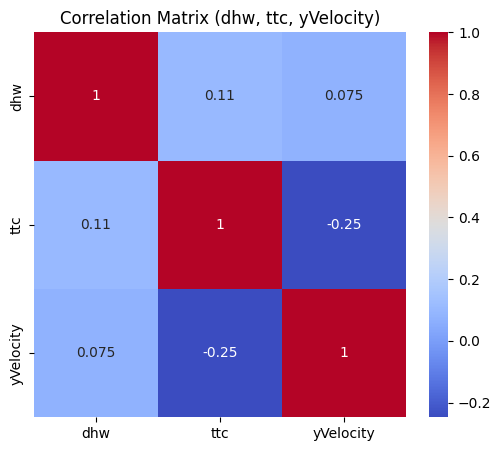

In [52]:

corr_matrix = df_behave[feature_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (dhw, ttc, yVelocity)")
plt.show()


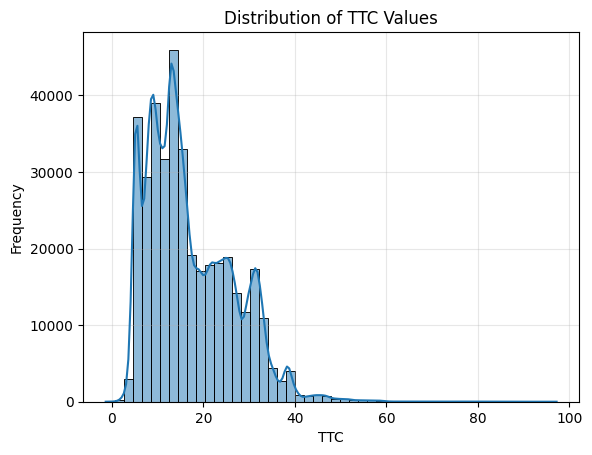

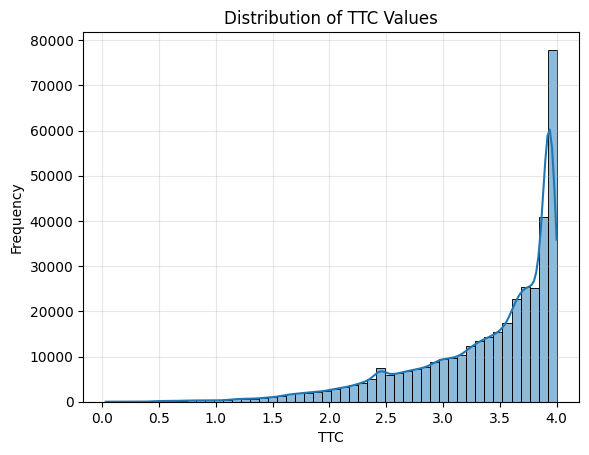

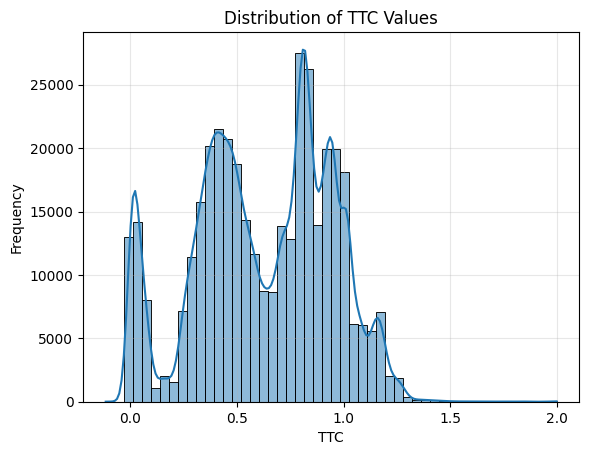

In [53]:
for col in feature_cols:
    plt.figure()
    sns.histplot(df_behave[col], kde=True, bins=50)
    plt.title('Distribution of TTC Values')
    plt.xlabel('TTC')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

In [54]:
dfd = (
    df_behave
    .groupby("id")
    .agg(
        Distance=("dhw", "mean"),
        lat_vel=("yVelocity", "mean"),
        minTTC=("ttc", "min")
    )
    .reset_index()
)


In [55]:
dfd

,id,Distance,lat_vel,minTTC
0,4.0,14.624392,0.117672,2.78
1,8.0,17.680000,1.236667,1.65
2,11.0,7.005000,0.080000,3.88
3,14.0,10.593821,0.924976,2.02
4,17.0,25.710784,0.798805,1.80
...,...,...,...,...
583,2804.0,10.424062,0.995994,2.96
584,2809.0,5.545638,0.064800,3.53
585,2812.0,12.011005,0.000000,3.07
586,2833.0,11.619597,0.930147,3.49


In [56]:
dfd["crash"] = dfd["minTTC"] < 1.5


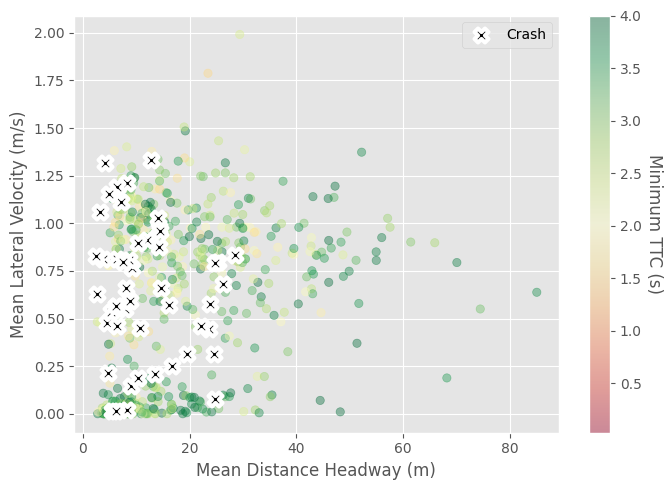

In [57]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(
    dfd["Distance"],
    dfd["lat_vel"],
    c=dfd["minTTC"],
    cmap=cm.RdYlGn,
    alpha=0.4
)

# Mark the crash
crash_df = dfd[dfd["crash"]]

ax.scatter(
    crash_df["Distance"],
    crash_df["lat_vel"],
    c="black",
    marker="X",
    s=100,
    linewidths=3,
    label="Crash",
    zorder=10,
    edgecolors="white"
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Minimum TTC (s)", rotation=270, labelpad=15)

ax.set_xlabel("Mean Distance Headway (m)")
ax.set_ylabel("Mean Lateral Velocity (m/s)")
ax.legend()

plt.tight_layout()
plt.show()


In [58]:
feature_matrix = stat_features.join(dynamic_features)

feature_matrix["style_label"] = (
    tracks_df.groupby("id")["style_label"].first()
)

feature_matrix.to_csv("feature_matrix.csv")


ValueError: columns overlap but no suffix specified: Index(['dhw_mean', 'dhw_std', 'yVelocity_mean', 'yVelocity_std'], dtype='object')

In [ ]:
dynamic_features = dynamic_features.rename(
    columns=lambda x: f"dyn_{x}"
)


In [ ]:
feature_matrix = stat_features.join(dynamic_features)


In [ ]:
df_behave

In [ ]:
feature_matrix["style_label"] = (
    df_behave.groupby("id")["driving_style_label"].first()
)


In [ ]:
feature_matrix.to_csv("feature_matrix.csv")


# Modellierung

### Modellierung in file 2